<small>
Propagate the translational state of JUICE, using point mass
gravity of Ganymede as the only acceleration acting on JUICE. For your
integrator/propagator, use:
<br>
• Ganymede as center of propagation;
<br>
• Runge-Kutta 4th order integration method with a step size of 10 s;
<br>
• Initial time t0 as per your student number (see cover page);
<br>
• Total propagation time = 344 hours.
</small>

<small>Importing Modules</small>

In [1]:
import os

import numpy as np
from IPython.core.pylabtools import figsize
from PIL.ImageColor import colormap
from matplotlib import pyplot as plt
from matplotlib.pyplot import subplots
from matplotlib import rcParams
from scipy.constants import mu_0
from tudatpy import constants
from tudatpy.data import save2txt
from tudatpy.interface import spice
from tudatpy.dynamics import environment_setup, propagation_setup, simulator
from tudatpy.astro import element_conversion


In [2]:
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 10
rcParams['axes.labelsize'] = 10
rcParams['xtick.labelsize'] = 8
rcParams['ytick.labelsize'] = 8
rcParams['legend.fontsize'] = 9

In [3]:
palette = {
    "pastel_blue"   : "#6AA7FF",
    "pastel_pink"   : "#FF82A9",
    "pastel_green"  : "#7ED6A6",
    "pastel_purple" : "#A894E8",
    "pastel_orange" : "#FFB27C",
    "pastel_teal"   : "#63D2C6"
}
palette_dark = {
    "electric_blue"   : "#4CC9F0",
    "neon_pink"       : "#F72585",
    "lime_green"      : "#80FF00",
    "bright_purple"   : "#B517FF",
    "cyber_orange"    : "#FF8800",
    "aqua_glow"       : "#00F5D4",
    "sun_yellow"      : "#FFD60A",
    "soft_white"      : "#EAEAEA"
}

In [4]:
# Retrieve current directory
current_directory = os.getcwd()

# student number: 1244779 --> 1244ABC
A = 4
B = 2
C = 6

In [5]:
simulation_start_epoch = (
    35.4 * constants.JULIAN_YEAR
    + A * 7.0 * constants.JULIAN_DAY
    + B * constants.JULIAN_DAY
    + C * constants.JULIAN_DAY / 24.0
)
simulation_end_epoch = simulation_start_epoch + 344.0 * constants.JULIAN_DAY / 24.0


<small>Create Environment</small>

In [6]:
# Load spice kernels.
spice.load_standard_kernels()
spice.load_kernel(current_directory + "/juice_mat_crema_5_1_150lb_v01.bsp")

# Create settings for celestial bodies
bodies_to_create = ["Ganymede"]
global_frame_origin = "Ganymede"
global_frame_orientation = "ECLIPJ2000"
body_settings = environment_setup.get_default_body_settings(
    bodies_to_create, global_frame_origin, global_frame_orientation
)

<small> Create Vehicle </small>

In [7]:
body_settings.add_empty_settings("JUICE")

# Create environment
bodies = environment_setup.create_system_of_bodies(body_settings)


<small> Create Accelerations </small>

In [8]:
# Define bodies that are propagated, and their central bodies of propagation.
bodies_to_propagate = ["JUICE"]
central_bodies = ["Ganymede"]

# Define accelerations acting on vehicle.
acceleration_settings_on_vehicle = dict(Ganymede = [propagation_setup.acceleration.point_mass_gravity()])

# Create global accelerations dictionary.
acceleration_settings = {"JUICE": acceleration_settings_on_vehicle}

# Create acceleration models.
acceleration_models = propagation_setup.create_acceleration_models(
    bodies, acceleration_settings, bodies_to_propagate, central_bodies
)

<small> Create Propagation Settings </small>

In [9]:
# Define initial state.
system_initial_state = spice.get_body_cartesian_state_at_epoch(
    target_body_name="JUICE",
    observer_body_name="Ganymede",
    reference_frame_name="ECLIPJ2000",
    aberration_corrections="NONE",
    ephemeris_time=simulation_start_epoch,
)

# Define required outputs
dependent_variables_to_save = [
    propagation_setup.dependent_variable.keplerian_state("JUICE", "Ganymede"),
]

# Create numerical integrator settings.
fixed_step_size = 10.0
integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step(
    fixed_step_size, coefficient_set=propagation_setup.integrator.CoefficientSets.rk_4
)

# Create propagation settings.
termination_settings = propagation_setup.propagator.time_termination(
    simulation_end_epoch
)
propagator_settings = propagation_setup.propagator.translational(
    central_bodies,
    acceleration_models,
    bodies_to_propagate,
    system_initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings,
    output_variables=dependent_variables_to_save,
)

propagator_settings.print_settings.print_initial_and_final_conditions = True

<small> Propagate Orbit </small>

In [10]:
# Create simulation object and propagate dynamics.
dynamics_simulator = simulator.create_dynamics_simulator(
    bodies, propagator_settings
)

# Retrieve all data produced by simulation
propagation_results = dynamics_simulator.propagation_results

# Extract numerical solution for states and dependent variables
state_history = propagation_results.state_history
dependent_variables = propagation_results.dependent_variable_history

<small> Save Results </small>

In [11]:
save2txt(
    solution=state_history, filename="JUICEPropagationHistory_Q1.dat", directory="./"
)

save2txt(
    solution=dependent_variables,
    filename="JUICEPropagationHistory_DependentVariables_Q1.dat",
    directory="./",
)

<small>Plot Results</small>

In [12]:
# Extract time and Kepler elements from dependent variables

kepler_elements = np.vstack(list(dependent_variables.values()))

time = dependent_variables.keys()
time_days = [
    t / constants.JULIAN_DAY - simulation_start_epoch / constants.JULIAN_DAY
    for t in time
]
print(kepler_elements.shape)


(123841, 6)


##### Question 1

###### a) Plot the change in JUICE’s Kepler elements w.r.t. those at t0 (e.g. the change in Kepler elements over time). Remove any jumps of 360 degrees/2π radians in angular elements, such that the curves you plot are continuous

In [13]:
# Extracting Keplerian Elements [a, e, i, w, RAAN, true_anomaly]
kepler_elements_p2 = np.array(kepler_elements - kepler_elements[0,:])  
a_num_p2 = kepler_elements_p2[:,0]                # Semi-major axis
e_num_p2 = kepler_elements_p2[:,1]                # Eccentricity
i_num_p2 = kepler_elements_p2[:,2]                # Inclination
w_num_p2 = kepler_elements_p2[:,3]                # Argument of Periapsis
RAAN_num_p2 = kepler_elements_p2[:,4]             # Longitude of Ascending Node (RAAN)
true_anomaly_num_p2 = kepler_elements_p2[:,5]     # True Anomaly

In [14]:
# Function to wrap the angle from -pi to +pi
def angle_wrap(object):
    '''
    :param object: the keplerian element whose angle in radians is to be wrapped (0 < angle < 360)
    :return: wrapped angle in degrees (-180 < angle < 180)
    '''

    object_unwrap = np.unwrap(object)
    object_deg = np.rad2deg(object_unwrap)
    # object_deg = (object_deg + 180) % 360 - 180

    return object_deg



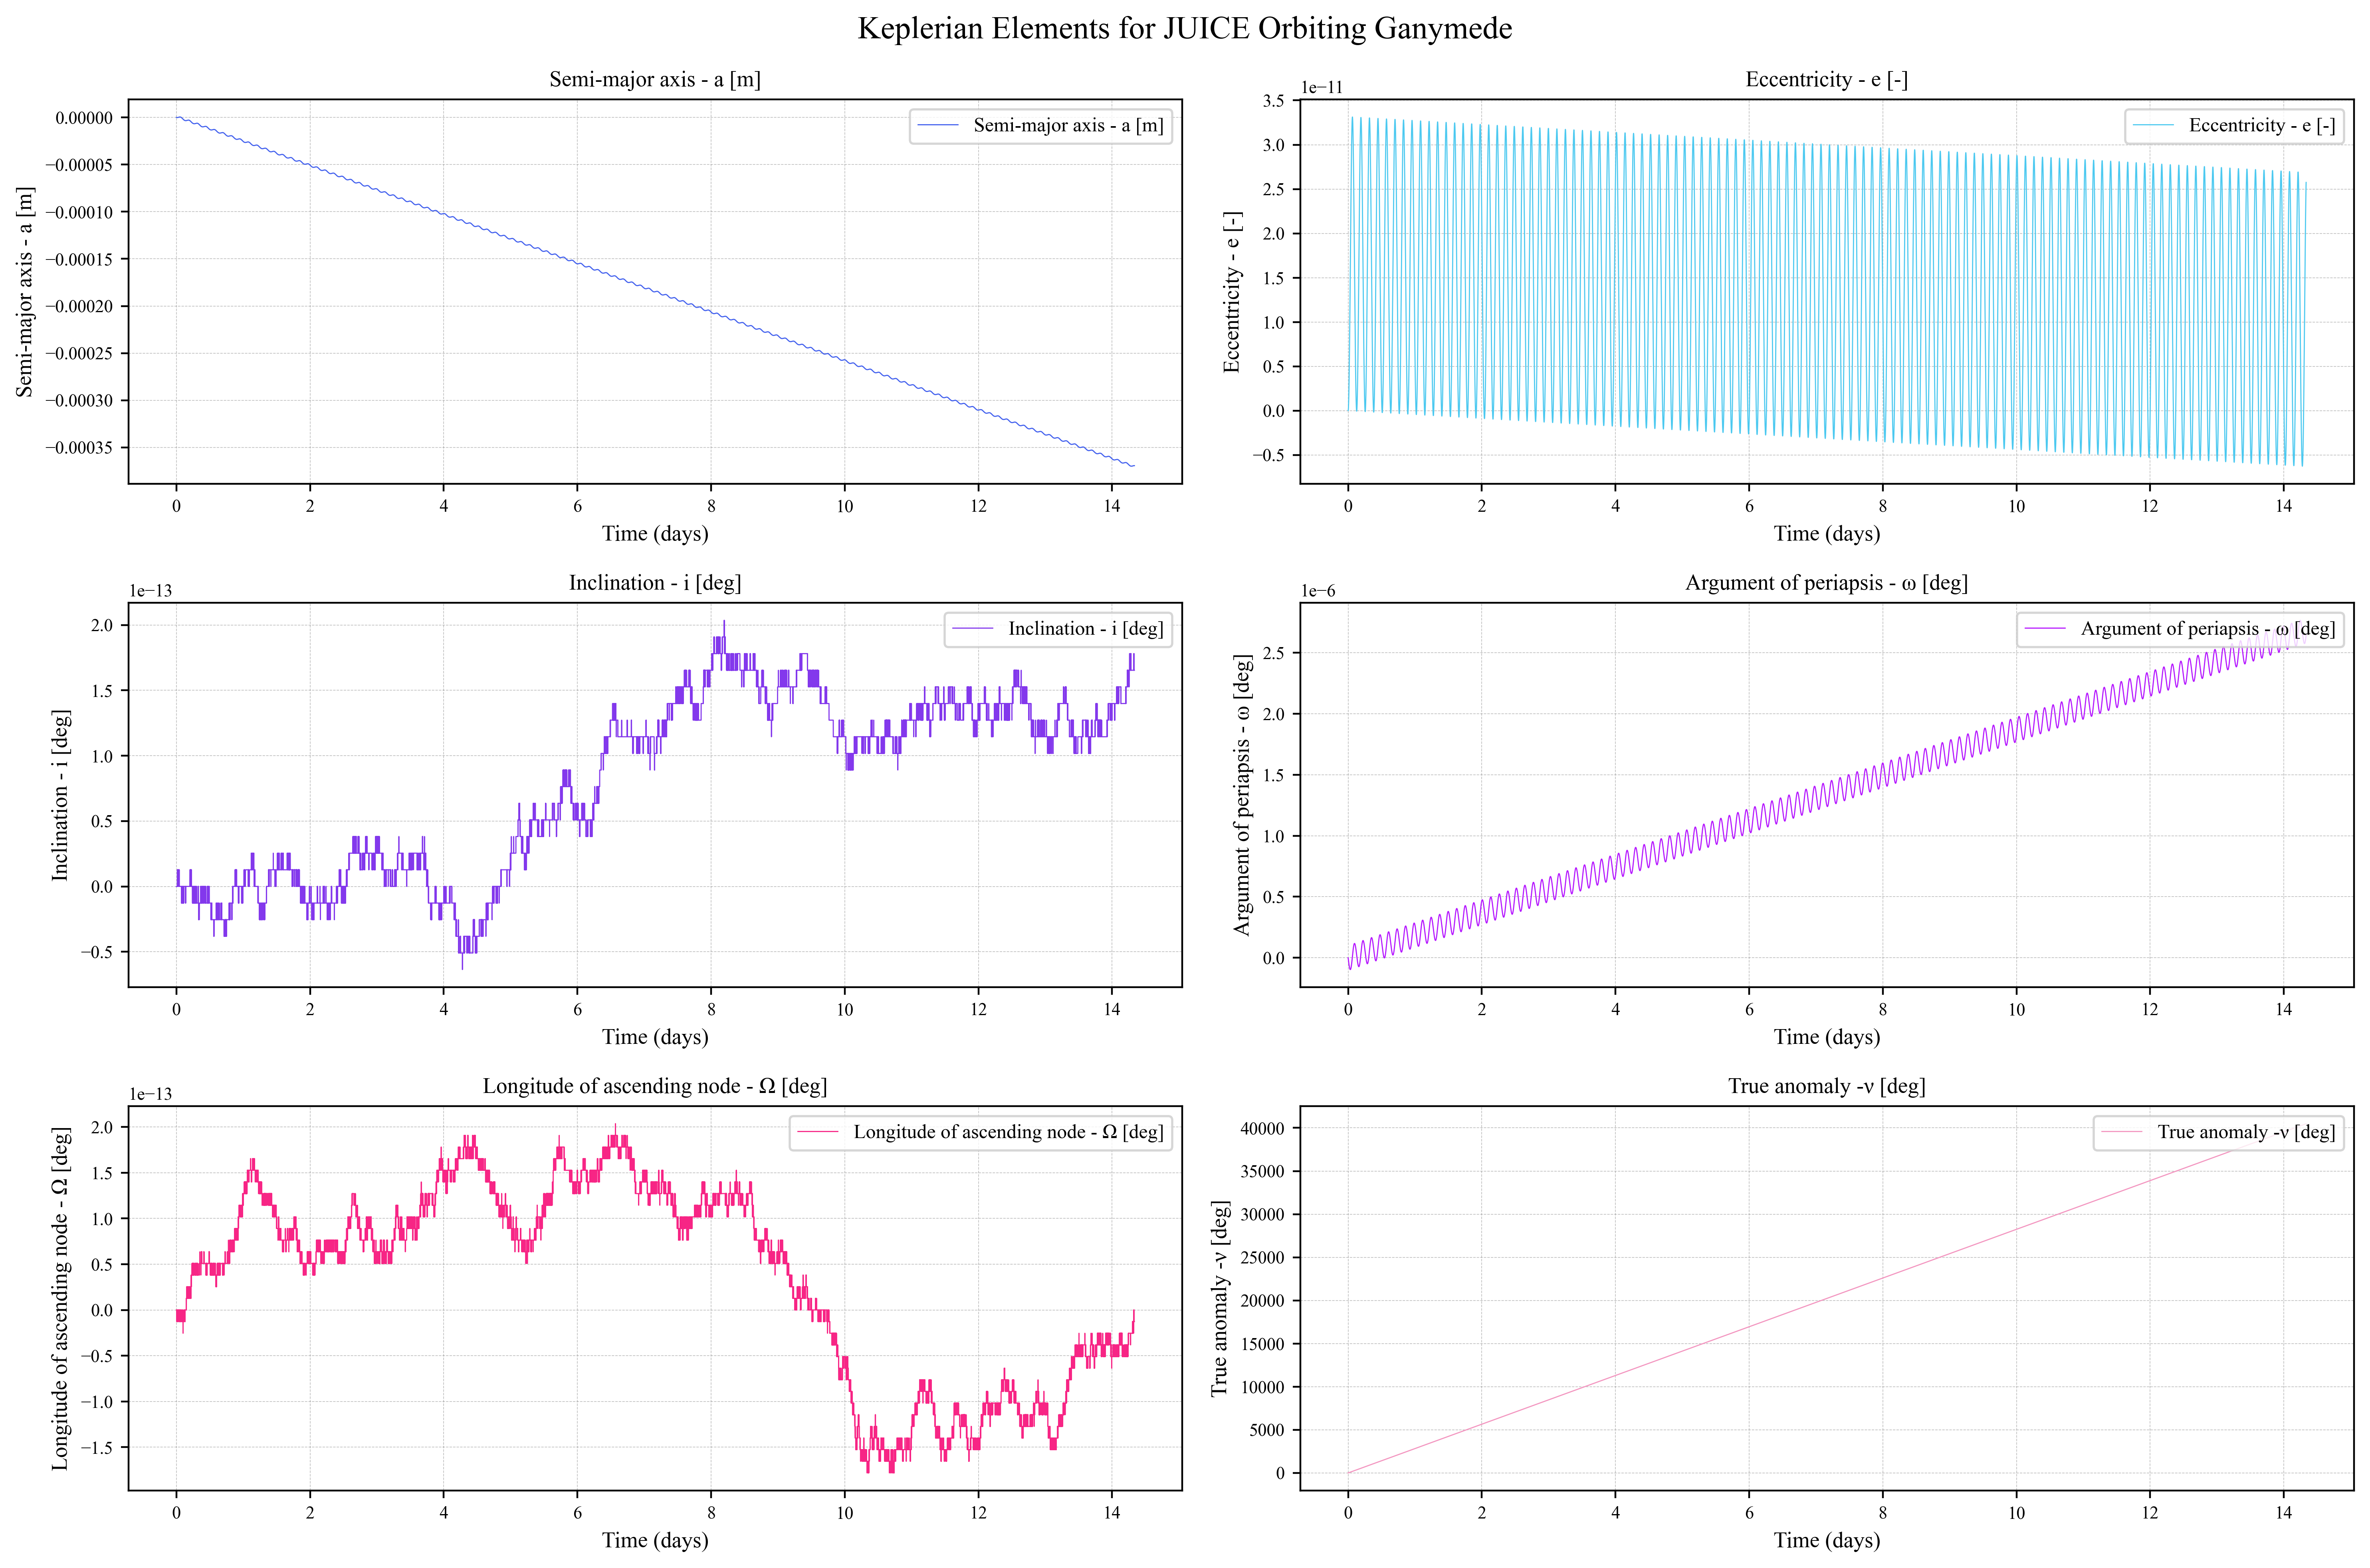

<Figure size 640x480 with 0 Axes>

In [15]:
# Keplerian Plot * in degrees

fig,ax = plt.subplots(nrows = 3, ncols = 2, sharex = False, sharey = False, dpi = 400, figsize = (15, 10))
ax = ax.flatten()

kep_ele = [a_num_p2, e_num_p2, angle_wrap(i_num_p2), angle_wrap(w_num_p2), angle_wrap(RAAN_num_p2), angle_wrap(true_anomaly_num_p2)]
labels = ["Semi-major axis - a [m]", "Eccentricity - e [-]", "Inclination - i [deg]", "Argument of periapsis - ω [deg]", "Longitude of ascending node - Ω [deg]", "True anomaly -ν [deg]"]
colors = [ "#4361EE","#4CC9F0", "#8338EC", "#B517FF", "#F72585", "#F396C0"]

for idx, (y, label, color) in enumerate(zip(kep_ele, labels, colors)):
    ax[idx].plot(time_days, y - y[0], label = label, color = color, linewidth = 0.5, linestyle = "-")
    ax[idx].set_xlabel("Time (days)")
    ax[idx].set_ylabel(label)
    ax[idx].grid(True, linestyle = "--", linewidth = 0.3, color = 'gray', alpha = 0.5)
    ax[idx].legend(loc = "upper right")
    ax[idx].set_title(label)

plt.suptitle("Keplerian Elements for JUICE Orbiting Ganymede")
plt.tight_layout()
plt.show()
plt.savefig('Keplerian_Elements_In_Deg.png')
plt.show()

<small> d) The analytical solution of the equations of motion defined here is a
purely Keplerian orbit. Based on this analytical solution, quantify
the error of the numerical integration procedure, in both Keplerian
and Cartesian elements, by creating figures of the difference between
the numerical result and the analytical solution (you may refer to
any relevant figures from 1a).</small>

In [16]:
# Convert Kepler to Cartesian
from tudatpy.astro.element_conversion import keplerian_to_cartesian

mu_G = bodies.get_body("Ganymede").gravitational_parameter

# keplerian_to_cartesian can convert one element at a time
x_c_ana = np.zeros((kepler_elements.shape[0],6))

for i in range(kepler_elements.shape[0]):
    kepler_element = kepler_elements[i,:].reshape((6,1))
    cartesian_state = keplerian_to_cartesian(keplerian_elements = kepler_element, gravitational_parameter = mu_G)
    x_c_ana[i,:] = cartesian_state.flatten()

In [17]:
from tudatpy.astro.element_conversion import keplerian_to_cartesian
from tudatpy.astro import two_body_dynamics

mu_G = bodies.get_body("Ganymede").gravitational_parameter

# ...Numerical Solutions...
# Cartesian State
x_c_num = np.vstack(list(state_history.values()))
# Keplerian State -->The numerical values for each keplerian element has been obtained from keplerian_elements --> named a_num, i_num....
x_kep_num = kepler_elements.copy()


# ...Analytical Solutions...

# pipeline:
# obtain initial keplerian state --> 2 body sys --> compute over time --> obtain keplerian states --> convert into cartesian states

# obtaining the initial pos and vel values from the initial keplerian state vector
abs_time = np.array(time_days).copy()
rel_time = abs_time - abs_time[0]
initial_kep_ele = kepler_elements[0,:]
x_kep_ana = np.zeros_like(x_kep_num)
x_c_ana = np.zeros_like(x_c_num)

for time_step in range(len(rel_time)):
    x_kep = two_body_dynamics.propagate_kepler_orbit(initial_kepler_elements = initial_kep_ele, propagation_time = rel_time[time_step] * constants.JULIAN_DAY, gravitational_parameter = mu_G)
    x_kep_ana[time_step] = x_kep

    x_c = keplerian_to_cartesian(x_kep, mu_G)
    x_c_ana[time_step] = x_c

In [18]:
# Computing Residuals
dr = x_c_num[:,0:3] - x_c_ana[:,0:3]
dv = x_c_num[:,3:6] - x_c_ana[:,3:6]

dr_norm = np.linalg.norm(dr, axis=1)
dv_norm = np.linalg.norm(dv, axis=1)

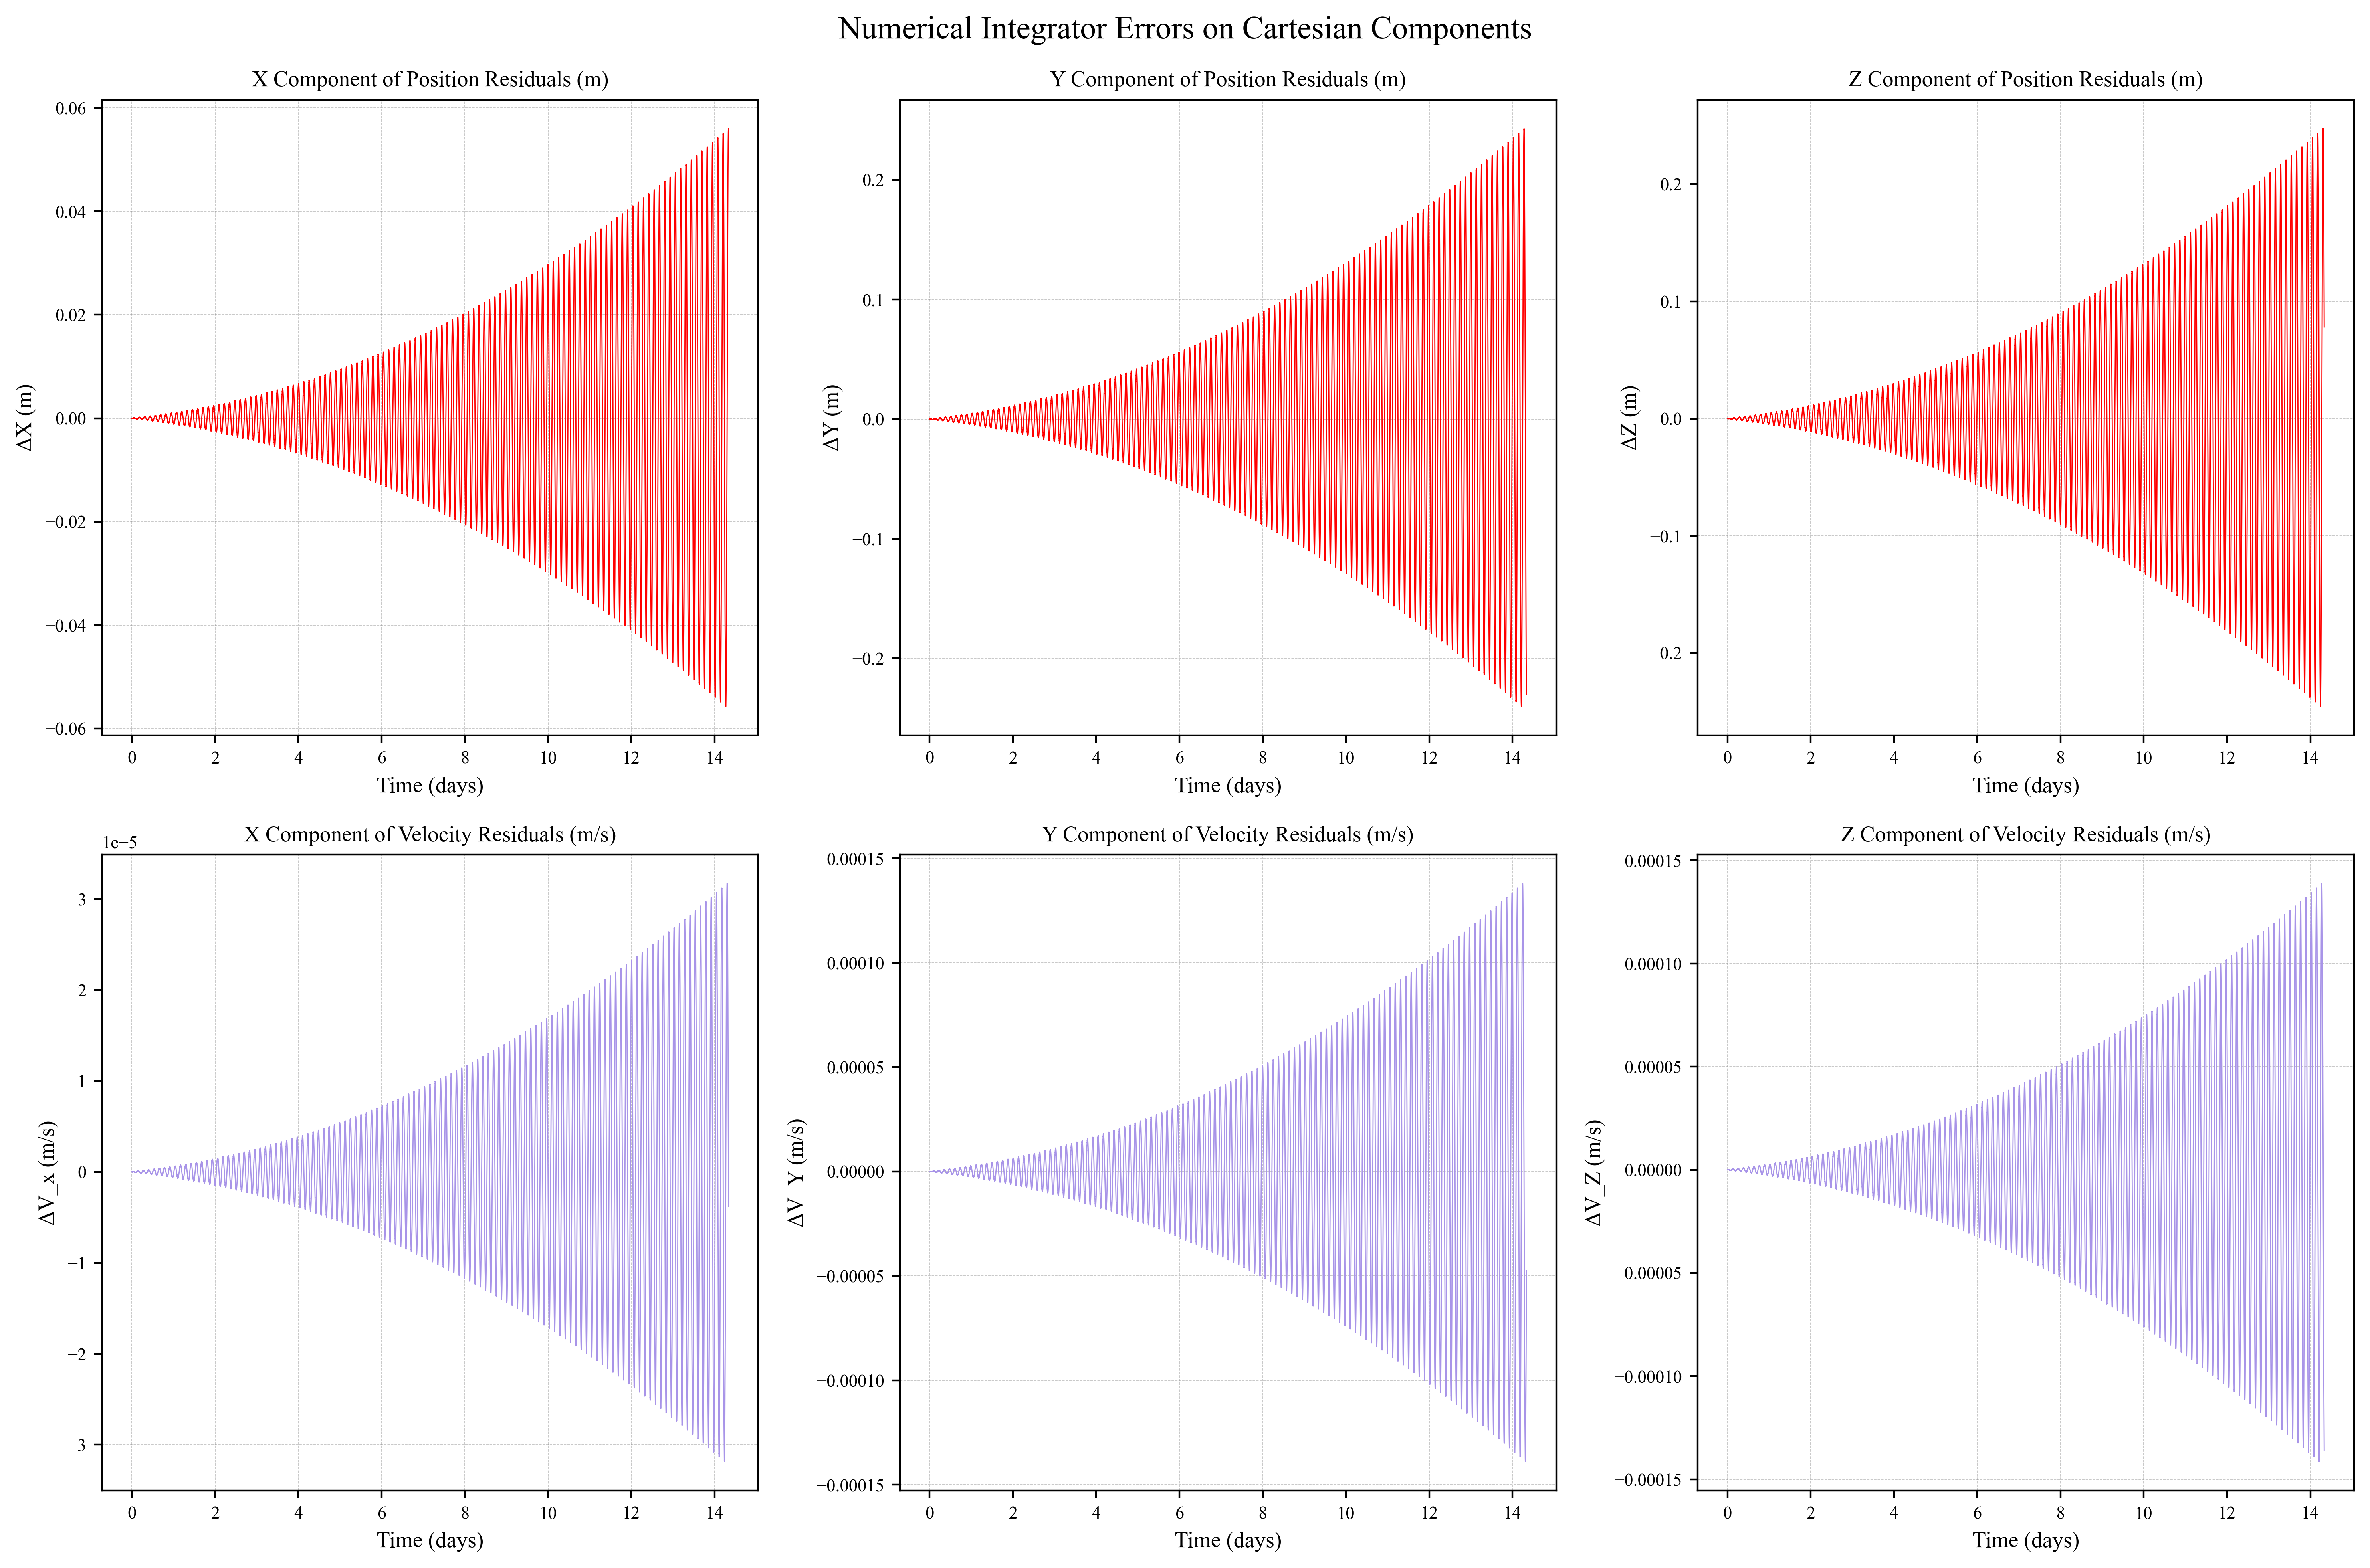

In [19]:
# Cartesian Residual Plot * in meters
fig, ax = plt.subplots(nrows = 2, ncols = 3, sharex = False, sharey = False, figsize = (15,10), dpi = 400)
ax = ax.flatten()
label = ('X', 'Y', 'Z', 'V_x', 'V_Y', 'V_Z')

for idx in range(3):
    ax[idx].plot(time_days, dr[:,idx], label = "Position Residual", color = 'red', linestyle = "-", linewidth = 0.5)
    ax[idx].set_xlabel("Time (days)")
    ax[idx].set_ylabel(f"Δ{label[idx]} (m)")
    ax[idx].set_title(f"{label[idx]} Component of Position Residuals (m)")
    ax[idx].grid(True, linestyle = "--", linewidth = 0.3, color = 'gray', alpha = 0.5)
    ax[idx+3].set_title(f"{label[idx]} Component of Velocity Residuals (m/s)")

for idx in range(3,6):
    ax[idx].plot(time_days, dv[:,idx-3], label = "Velocity Residual", color = palette["pastel_purple"], linestyle = "-", linewidth = 0.5 )
    ax[idx].set_xlabel("Time (days)")
    ax[idx].set_ylabel(f"Δ{label[idx]} (m/s)")
    ax[idx].grid(True, linestyle = "--", linewidth = 0.3, color = 'gray', alpha = 0.5)



plt.suptitle("Numerical Integrator Errors on Cartesian Components")
plt.tight_layout()
plt.show()


In [20]:
# Computing Residuals
# Extracting Keplerian Elements [a, e, i, w, RAAN, true_anomaly]

a_ana = x_kep_ana[:,0]                # Semi-major axis
e_ana = x_kep_ana[:,1]                # Eccentricity
i_ana = x_kep_ana[:,2]                # Inclination
w_ana = x_kep_ana[:,3]                # Argument of Periapsis
RAAN_ana = x_kep_ana[:,4]             # Longitude of Ascending Node (RAAN)
true_anomaly_ana = x_kep_ana[:,5]     # True Anomaly

In [21]:
# Extracting Keplerian Elements [a, e, i, w, RAAN, true_anomaly]

a_num = kepler_elements[:,0]                # Semi-major axis
e_num = kepler_elements[:,1]                # Eccentricity
i_num = kepler_elements[:,2]                # Inclination
w_num = kepler_elements[:,3]                # Argument of Periapsis
RAAN_num = kepler_elements[:,4]             # Longitude of Ascending Node (RAAN)
true_anomaly_num = kepler_elements[:,5]     # True Anomaly

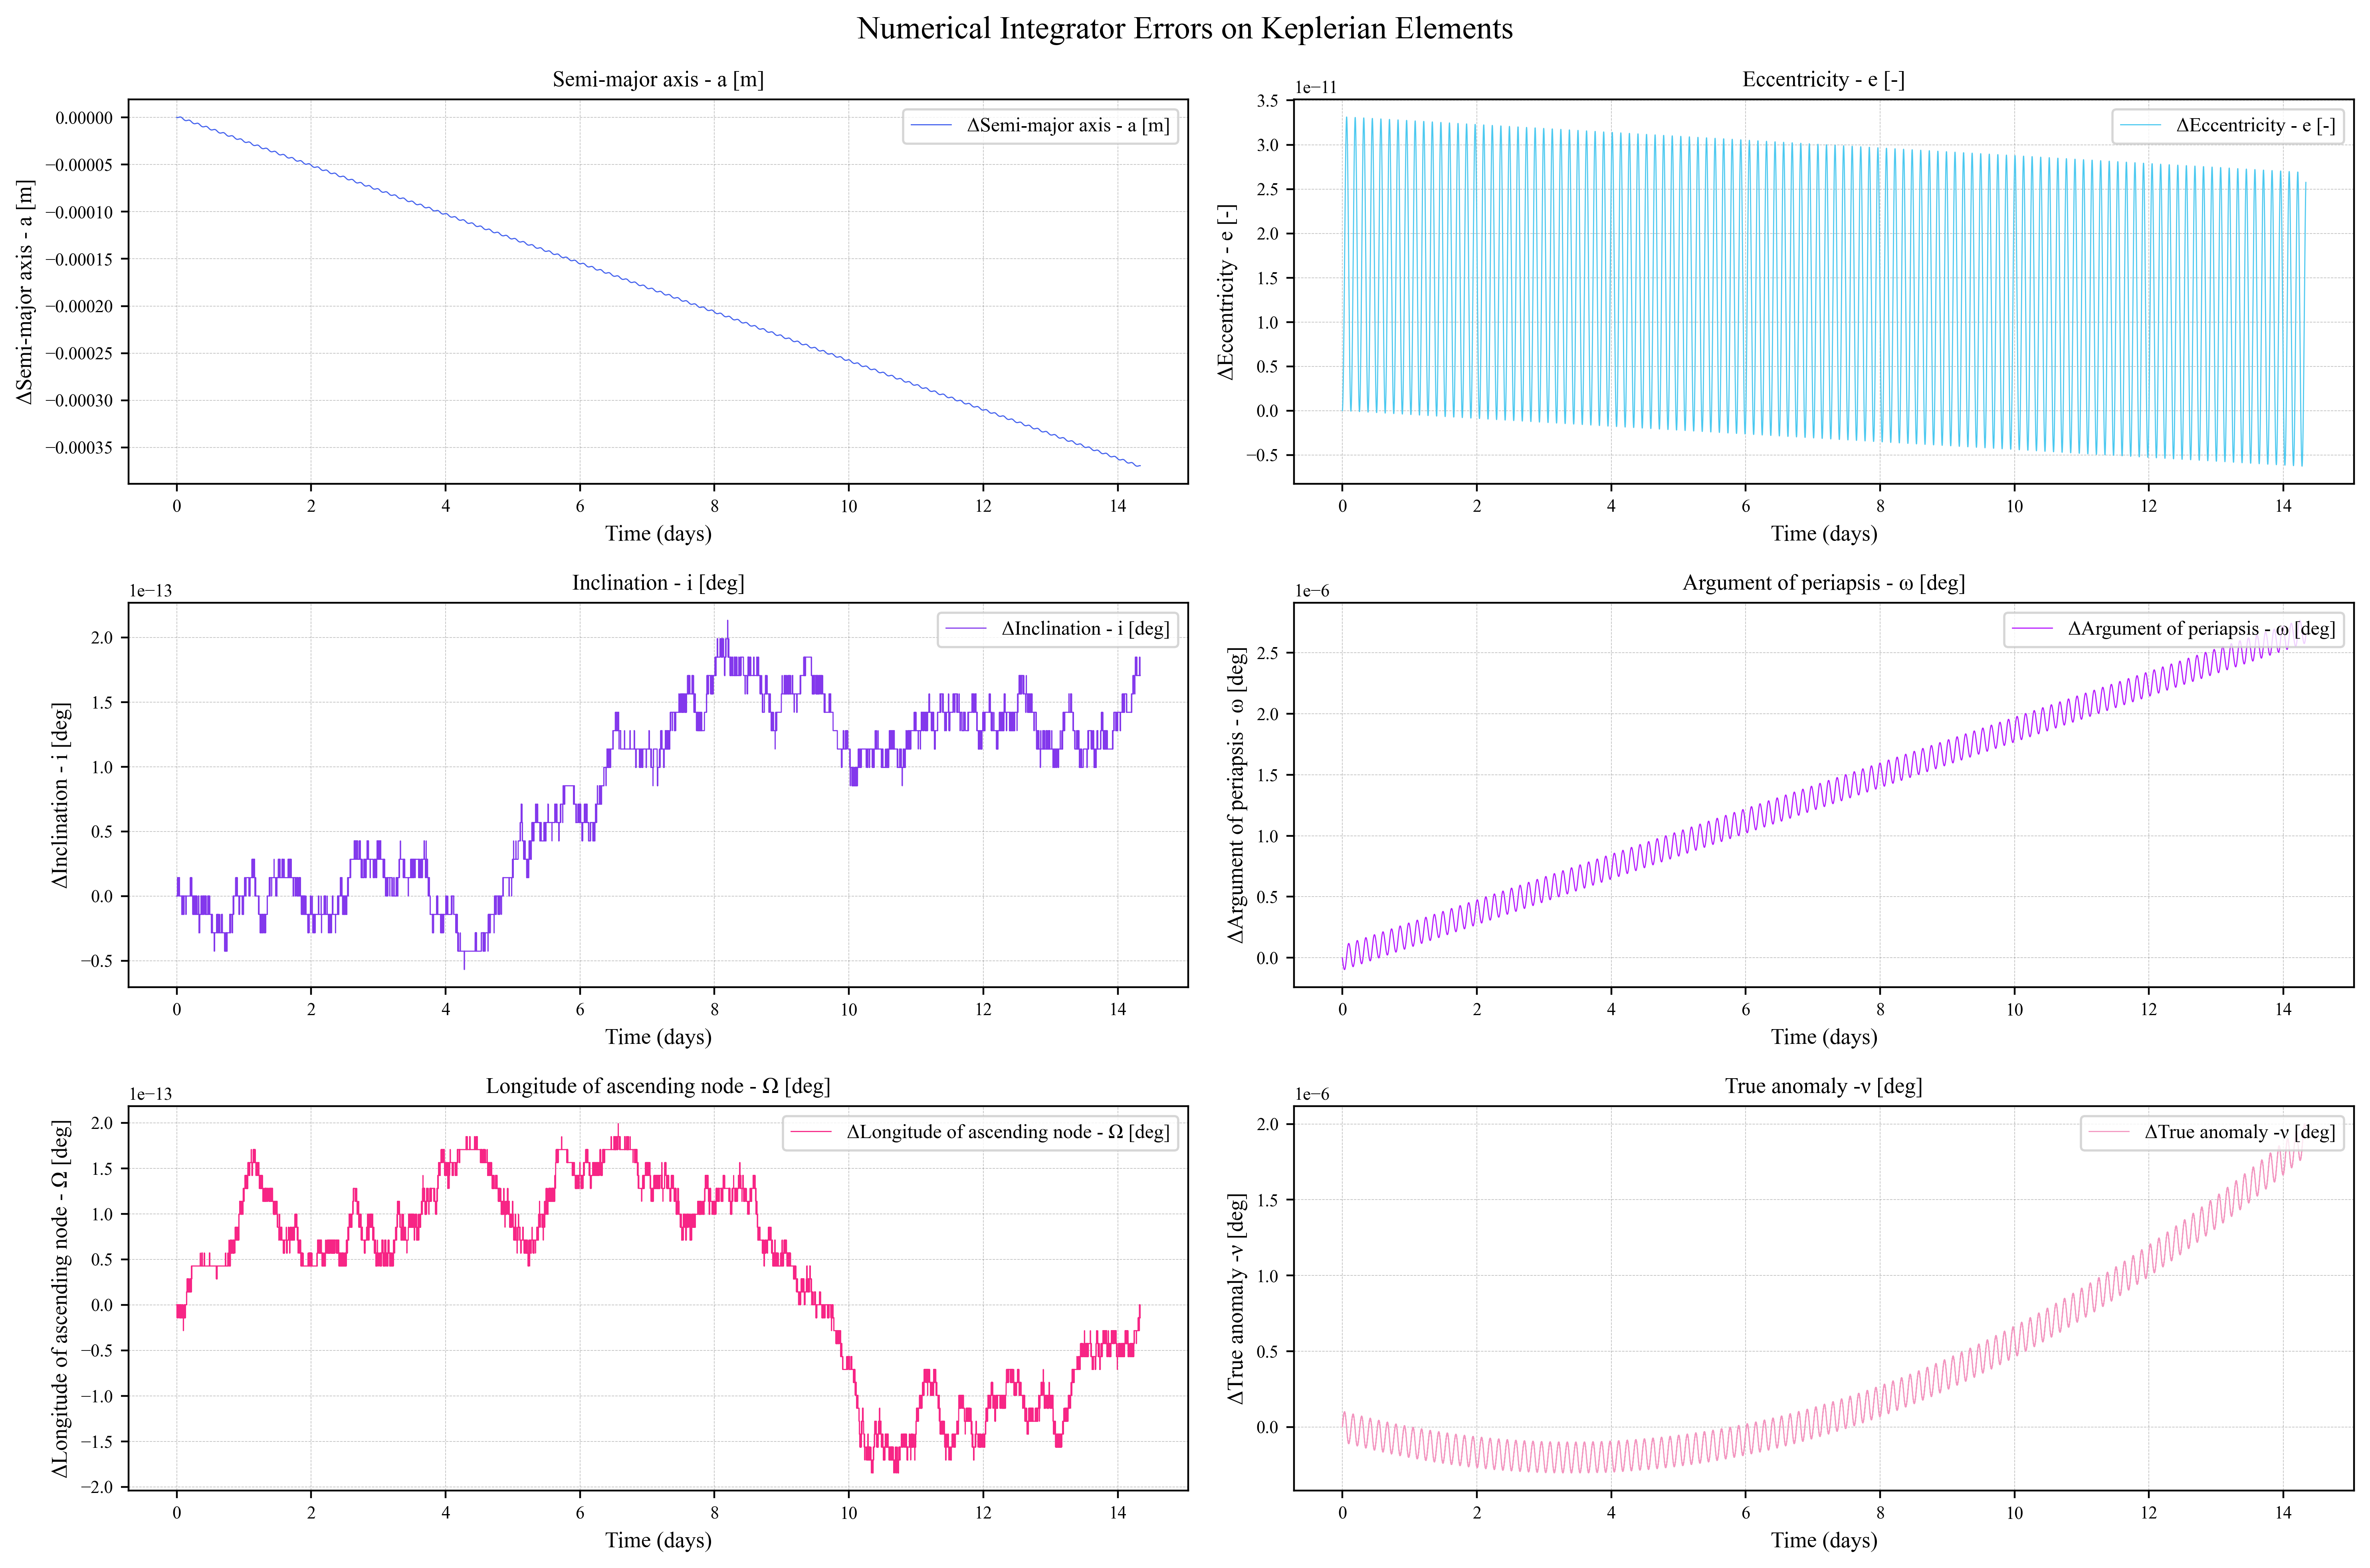

In [22]:
# Keplerian Residual Plot * in degrees

fig,ax = plt.subplots(nrows = 3, ncols = 2, sharex = False, sharey = False, dpi = 400, figsize = (15, 10))
ax = ax.flatten()

kep_ele_ana = [a_ana, e_ana, angle_wrap(i_ana), angle_wrap(w_ana), angle_wrap(RAAN_ana), angle_wrap(true_anomaly_ana)]
kep_ele_num = [a_num, e_num, angle_wrap(i_num), angle_wrap(w_num), angle_wrap(RAAN_num), angle_wrap(true_anomaly_num)]
kep_residuals = np.array(kep_ele_num) - np.array(kep_ele_ana)

title = ["Semi-major axis - a [m]", "Eccentricity - e [-]", "Inclination - i [deg]", "Argument of periapsis - ω [deg]", "Longitude of ascending node - Ω [deg]", "True anomaly -ν [deg]"]
labels = ["ΔSemi-major axis - a [m]", "ΔEccentricity - e [-]", "ΔInclination - i [deg]", "ΔArgument of periapsis - ω [deg]", "ΔLongitude of ascending node - Ω [deg]", "ΔTrue anomaly -ν [deg]"]

colors = [ "#4361EE","#4CC9F0", "#8338EC", "#B517FF", "#F72585", "#F396C0"]
for idx, (title, label, color) in enumerate(zip(title, labels, colors)):
    ax[idx].plot(time_days, kep_residuals[idx], label = label, color = color, linewidth = 0.5, linestyle = "-")
    ax[idx].set_xlabel("Time (days)")
    ax[idx].set_ylabel(label)
    ax[idx].grid(True, linestyle = "--", linewidth = 0.3, color = 'gray', alpha = 0.5)
    ax[idx].legend(loc = "upper right")
    ax[idx].set_title(title)

plt.suptitle("Numerical Integrator Errors on Keplerian Elements")
plt.tight_layout()
plt.show()